In [1]:
# Cell 1: (Optional) Install dependencies + Force TensorFlow CPU-only

import os

# Force CPU only (run before importing tensorflow)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("✅ CPU-only mode set (CUDA_VISIBLE_DEVICES = -1)")

# OPTIONAL installs (uncomment if needed)
# !pip -q install ultralytics opencv-python tensorflow pillow matplotlib

print("✅ If you saw no errors above, you're ready to continue.")


✅ CPU-only mode set (CUDA_VISIBLE_DEVICES = -1)
✅ If you saw no errors above, you're ready to continue.


In [3]:
# Cell 2: Imports + Path configuration + Basic checks

from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from ultralytics import YOLO

# Inputs
IMAGE_PATH = Path("man.png")
POSE_MODEL_PATH = Path("yolov8n-pose.pt")

UPPER_MODEL_PATH = Path("upper_body_classifier-mobilenetv2.h5")
LOWER_MODEL_PATH = Path("lower_body_mobilenetv2.h5")

# Outputs
UPPER_OUT = Path("upper.png")
LOWER_OUT = Path("lower.png")

print("✅ Paths configured")
print("🖼️ Image:", IMAGE_PATH.resolve())
print("🧍 Pose model:", POSE_MODEL_PATH.resolve())
print("👕 Upper classifier:", UPPER_MODEL_PATH.resolve())
print("👖 Lower classifier:", LOWER_MODEL_PATH.resolve())

print("\n🔎 Checking files...")
print("   man.png exists:", IMAGE_PATH.exists())
print("   yolov8n-pose.pt exists:", POSE_MODEL_PATH.exists())
print("   upper model exists:", UPPER_MODEL_PATH.exists())
print("   lower model exists:", LOWER_MODEL_PATH.exists())

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"❌ Image not found: {IMAGE_PATH.resolve()}")
if not POSE_MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Pose model not found: {POSE_MODEL_PATH.resolve()}")
if not UPPER_MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Upper model not found: {UPPER_MODEL_PATH.resolve()}")
if not LOWER_MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Lower model not found: {LOWER_MODEL_PATH.resolve()}")

print("\n✅ Environment OK")
print("🧠 TensorFlow:", tf.__version__)
print("🎮 GPUs visible:", len(tf.config.list_physical_devices("GPU")))


2026-02-02 10:50:48.014799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770029448.035299    2026 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770029448.041890    2026 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770029448.057333    2026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770029448.057350    2026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770029448.057352    2026 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Paths configured
🖼️ Image: /workspace/pipeline/man.png
🧍 Pose model: /workspace/pipeline/yolov8n-pose.pt
👕 Upper classifier: /workspace/pipeline/upper_body_classifier-mobilenetv2.h5
👖 Lower classifier: /workspace/pipeline/lower_body_mobilenetv2.h5

🔎 Checking files...
   man.png exists: True
   yolov8n-pose.pt exists: True
   upper model exists: True
   lower model exists: True

✅ Environment OK
🧠 TensorFlow: 2.19.0
🎮 GPUs visible: 0


2026-02-02 10:50:52.622012: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
# Cell 3: Load image + Load YOLOv8 pose model

print("🔄 Loading image with OpenCV...")
img_bgr = cv2.imread(str(IMAGE_PATH))
if img_bgr is None:
    raise ValueError("❌ OpenCV could not read man.png (is it a valid image?)")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(f"✅ Image loaded: shape={img_rgb.shape} (HxW={h}x{w})")

print("🔄 Loading YOLOv8 pose model...")
pose_model = YOLO(str(POSE_MODEL_PATH))
print("✅ Pose model loaded")


🔄 Loading image with OpenCV...
✅ Image loaded: shape=(575, 212, 3) (HxW=575x212)
🔄 Loading YOLOv8 pose model...
✅ Pose model loaded


🚀 Running pose inference...
✅ Main person bbox selected:
   x1=40, y1=12, x2=211, y2=570
✅ Hip-based split found at y=275
✅ Saved crops:
   upper.png -> /workspace/pipeline/upper.png shape: (263, 171, 3)
   lower.png -> /workspace/pipeline/lower.png shape: (295, 171, 3)


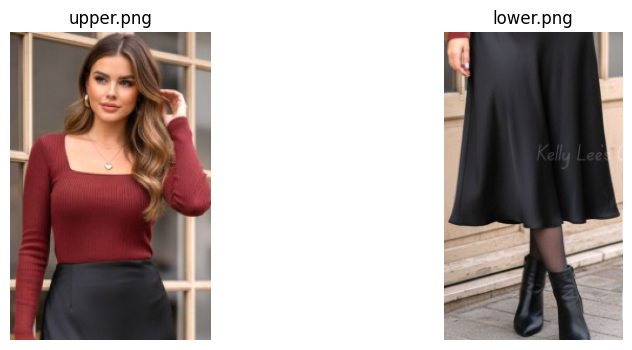

In [5]:
# Cell 4: Run pose inference + Split into upper.png and lower.png

print("🚀 Running pose inference...")
results = pose_model.predict(source=str(IMAGE_PATH), verbose=False)

if not results or len(results) == 0:
    raise RuntimeError("❌ No results returned by YOLO.")

r0 = results[0]

if r0.boxes is None or len(r0.boxes) == 0:
    raise RuntimeError("❌ No person detected (no bounding boxes).")

# Choose the largest detected box (assume it's the main person)
boxes_xyxy = r0.boxes.xyxy.cpu().numpy()  # (N, 4)
areas = (boxes_xyxy[:, 2] - boxes_xyxy[:, 0]) * (boxes_xyxy[:, 3] - boxes_xyxy[:, 1])
best_idx = int(np.argmax(areas))
x1, y1, x2, y2 = boxes_xyxy[best_idx]

# Clamp
x1, y1, x2, y2 = map(int, [max(0, x1), max(0, y1), min(w - 1, x2), min(h - 1, y2)])

print("✅ Main person bbox selected:")
print(f"   x1={x1}, y1={y1}, x2={x2}, y2={y2}")

# Try to use hips keypoints for a natural split
y_split = None
try:
    kpts = r0.keypoints.xy.cpu().numpy()  # (N, 17, 2) for COCO pose
    # best person's keypoints
    person_kpts = kpts[best_idx]  # (17,2)

    # COCO indices: 11 left_hip, 12 right_hip
    lh = person_kpts[11]
    rh = person_kpts[12]

    # If hips are present and non-zero, use their average y
    if (lh[0] > 0 and lh[1] > 0) and (rh[0] > 0 and rh[1] > 0):
        y_split = int((lh[1] + rh[1]) / 2.0)
        print(f"✅ Hip-based split found at y={y_split}")
    else:
        print("⚠️ Hip keypoints not reliable; using fallback split.")
except Exception as e:
    print("⚠️ Could not read keypoints; using fallback split.")
    print("   Error:", str(e))

# Fallback split: 55% of bbox height
if y_split is None:
    y_split = int(y1 + 0.55 * (y2 - y1))
    print(f"✅ Fallback split at y={y_split} (55% of bbox height)")

# Ensure split is inside bbox
y_split = max(y1 + 1, min(y2 - 1, y_split))

# Crop within bbox region
upper_crop = img_rgb[y1:y_split, x1:x2]
lower_crop = img_rgb[y_split:y2, x1:x2]

if upper_crop.size == 0 or lower_crop.size == 0:
    raise RuntimeError("❌ Cropping failed (empty upper or lower crop). Check detection/split.")

# Save
cv2.imwrite(str(UPPER_OUT), cv2.cvtColor(upper_crop, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(LOWER_OUT), cv2.cvtColor(lower_crop, cv2.COLOR_RGB2BGR))

print("✅ Saved crops:")
print("   upper.png ->", UPPER_OUT.resolve(), "shape:", upper_crop.shape)
print("   lower.png ->", LOWER_OUT.resolve(), "shape:", lower_crop.shape)

# (Optional) preview
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(upper_crop); plt.axis("off"); plt.title("upper.png")
plt.subplot(1,2,2); plt.imshow(lower_crop); plt.axis("off"); plt.title("lower.png")
plt.show()


In [6]:
# Cell 5: Helper utilities (class name handling + preprocessing + decoding)

def normalize_label(s: str) -> str:
    """Normalize class labels for robust matching."""
    s = str(s).strip().lower()
    s = s.replace("-", " ").replace("_", " ")
    s = " ".join(s.split())
    return s

def preprocess_for_mobilenetv2(image_path: Path, img_size=(224, 224)) -> np.ndarray:
    """Matches your 4.1/4.2 inference style: resize -> to array -> /255 -> expand dims."""
    img = load_img(image_path, target_size=img_size)
    arr = img_to_array(img).astype("float32") / 255.0
    return np.expand_dims(arr, axis=0)

def topk_from_probs(probs: np.ndarray, class_names: list[str], k=3):
    idxs = np.argsort(probs)[::-1][:k]
    out = []
    for i in idxs:
        name = class_names[int(i)] if int(i) < len(class_names) else f"index_{int(i)}"
        out.append((int(i), name, float(probs[int(i)])))
    return out

print("✅ Helper functions ready")


✅ Helper functions ready


In [7]:
# Cell 6: 4.1 Inference (Upper body) - upper.png -> upper_body_classifier-mobilenetv2.h5

print("🔄 [4.1] Loading UPPER model...")
upper_model = load_model(UPPER_MODEL_PATH)
print("✅ [4.1] Upper model loaded")
print("   input:", upper_model.input_shape, "| output:", upper_model.output_shape)

# If you *know* the true class order is different, update this list to match training order.
UPPER_CLASS_NAMES = [
    "blouse", "crop top", "hoodie", "shirt", "sweater", "tank top", "tshirt"
]
UPPER_CLASS_NAMES_NORM = [normalize_label(x) for x in UPPER_CLASS_NAMES]

print("\n🧾 [4.1] Upper classes (assumed order):", UPPER_CLASS_NAMES)

print("\n🔄 [4.1] Preprocessing upper.png...")
upper_input = preprocess_for_mobilenetv2(UPPER_OUT)
print("✅ [4.1] upper input shape:", upper_input.shape)

print("\n🚀 [4.1] Predicting upper clothing class...")
upper_probs = upper_model.predict(upper_input, verbose=0)[0]
print("✅ [4.1] Prediction done. probs shape:", upper_probs.shape)

upper_top1_idx = int(np.argmax(upper_probs))
upper_top1_class = UPPER_CLASS_NAMES[upper_top1_idx] if upper_top1_idx < len(UPPER_CLASS_NAMES) else f"index_{upper_top1_idx}"
upper_top1_conf = float(upper_probs[upper_top1_idx])

print("\n✅ [4.1] Top-1 UPPER prediction:")
print(f"   Class: {upper_top1_class}")
print(f"   Confidence: {upper_top1_conf:.4f} ({upper_top1_conf*100:.2f}%)")

print("\n🏆 [4.1] Top-3 UPPER predictions:")
for rank, (idx, name, conf) in enumerate(topk_from_probs(upper_probs, UPPER_CLASS_NAMES, k=3), 1):
    print(f"   {rank}. {name:15s} -> {conf:.4f} ({conf*100:.2f}%)")

# Suitability rule (your requirement):
# If hoodie or sweater => NOT suitable; otherwise suitable.
upper_pred_norm = normalize_label(upper_top1_class)
upper_not_suitable = upper_pred_norm in {normalize_label("hoodie"), normalize_label("sweater")}

print("\n📌 [4.1] Upper suitability decision:")
if upper_not_suitable:
    print("❌ NOT SUITABLE (hoodie/sweater detected)")
else:
    print("✅ SUITABLE")


🔄 [4.1] Loading UPPER model...


✅ [4.1] Upper model loaded
   input: (None, 224, 224, 3) | output: (None, 7)

🧾 [4.1] Upper classes (assumed order): ['blouse', 'crop top', 'hoodie', 'shirt', 'sweater', 'tank top', 'tshirt']

🔄 [4.1] Preprocessing upper.png...
✅ [4.1] upper input shape: (1, 224, 224, 3)

🚀 [4.1] Predicting upper clothing class...
✅ [4.1] Prediction done. probs shape: (7,)

✅ [4.1] Top-1 UPPER prediction:
   Class: tank top
   Confidence: 0.5546 (55.46%)

🏆 [4.1] Top-3 UPPER predictions:
   1. tank top        -> 0.5546 (55.46%)
   2. crop top        -> 0.1950 (19.50%)
   3. shirt           -> 0.0975 (9.75%)

📌 [4.1] Upper suitability decision:
✅ SUITABLE


In [8]:
# Cell 7: 4.2 Inference (Lower body) - lower.png -> lower_body_mobilenetv2.h5

print("🔄 [4.2] Loading LOWER model...")
lower_model = load_model(LOWER_MODEL_PATH)
print("✅ [4.2] Lower model loaded")
print("   input:", lower_model.input_shape, "| output:", lower_model.output_shape)

# If you *know* the true class order is different, update this list to match training order.
LOWER_CLASS_NAMES = [
    "cargo pants", "culottes", "shorts", "skirt", "trousers"
]
LOWER_CLASS_NAMES_NORM = [normalize_label(x) for x in LOWER_CLASS_NAMES]

print("\n🧾 [4.2] Lower classes (assumed order):", LOWER_CLASS_NAMES)

print("\n🔄 [4.2] Preprocessing lower.png...")
lower_input = preprocess_for_mobilenetv2(LOWER_OUT)
print("✅ [4.2] lower input shape:", lower_input.shape)

print("\n🚀 [4.2] Predicting lower clothing class...")
lower_probs = lower_model.predict(lower_input, verbose=0)[0]
print("✅ [4.2] Prediction done. probs shape:", lower_probs.shape)

lower_top1_idx = int(np.argmax(lower_probs))
lower_top1_class = LOWER_CLASS_NAMES[lower_top1_idx] if lower_top1_idx < len(LOWER_CLASS_NAMES) else f"index_{lower_top1_idx}"
lower_top1_conf = float(lower_probs[lower_top1_idx])

print("\n✅ [4.2] Top-1 LOWER prediction:")
print(f"   Class: {lower_top1_class}")
print(f"   Confidence: {lower_top1_conf:.4f} ({lower_top1_conf*100:.2f}%)")

print("\n🏆 [4.2] Top-3 LOWER predictions:")
for rank, (idx, name, conf) in enumerate(topk_from_probs(lower_probs, LOWER_CLASS_NAMES, k=3), 1):
    print(f"   {rank}. {name:15s} -> {conf:.4f} ({conf*100:.2f}%)")

# Suitability rule (your requirement):
# If cargo pants, culottes, or skirt => NOT suitable; otherwise suitable.
lower_pred_norm = normalize_label(lower_top1_class)
lower_not_suitable = lower_pred_norm in {
    normalize_label("cargo pants"),
    normalize_label("culottes"),
    normalize_label("skirt"),
}

print("\n📌 [4.2] Lower suitability decision:")
if lower_not_suitable:
    print("❌ NOT SUITABLE (cargo pants/culottes/skirt detected)")
else:
    print("✅ SUITABLE")


🔄 [4.2] Loading LOWER model...


✅ [4.2] Lower model loaded
   input: (None, 224, 224, 3) | output: (None, 5)

🧾 [4.2] Lower classes (assumed order): ['cargo pants', 'culottes', 'shorts', 'skirt', 'trousers']

🔄 [4.2] Preprocessing lower.png...
✅ [4.2] lower input shape: (1, 224, 224, 3)

🚀 [4.2] Predicting lower clothing class...
✅ [4.2] Prediction done. probs shape: (5,)

✅ [4.2] Top-1 LOWER prediction:
   Class: culottes
   Confidence: 0.8892 (88.92%)

🏆 [4.2] Top-3 LOWER predictions:
   1. culottes        -> 0.8892 (88.92%)
   2. skirt           -> 0.0742 (7.42%)
   3. shorts          -> 0.0138 (1.38%)

📌 [4.2] Lower suitability decision:
❌ NOT SUITABLE (cargo pants/culottes/skirt detected)


In [9]:
# Cell 8: Final decision for BMI test

print("🧾 Final Summary")
print("   Upper predicted:", upper_top1_class, f"({upper_top1_conf*100:.2f}%)")
print("   Lower predicted:", lower_top1_class, f"({lower_top1_conf*100:.2f}%)")

if upper_not_suitable or lower_not_suitable:
    print("\n❌ not suitable for the BMI test")
else:
    print("\n✅ suitable for the BMI test")


🧾 Final Summary
   Upper predicted: tank top (55.46%)
   Lower predicted: culottes (88.92%)

❌ not suitable for the BMI test
